In [15]:
# Import modules

import rdkit
from IPython.display import SVG
from notebook_utils import draw_molecule
from rdkit.Chem import Descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize

# Suppress RDKit Output
rdkit.RDLogger.DisableLog("rdApp.*")

# Print versions
print(f"RDKit Version: {rdkit.__version__}")

RDKit Version: 2026.03.1


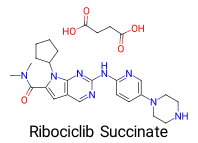

In [16]:
# Example molecule
smiles = "CN(C)C(=O)c1cc2cnc(Nc3ccc(N4CCNCC4)cn3)nc2n1C1CCCC1.O=C(O)CCC(=O)O"
name = "Ribociclib Succinate"
mol = rdkit.Chem.MolFromSmiles(smiles)

# Draw molecule
img = draw_molecule(mol, legend=name, acs_style=True)
SVG(img)

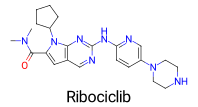

In [17]:
# Standardize the molecule
try:
    mol = rdMolStandardize.Cleanup(mol)
    mol = rdMolStandardize.FragmentParent(mol)
    uncharge_app = rdMolStandardize.Uncharger()
    mol = uncharge_app.uncharge(mol)
    tautomer_app = rdMolStandardize.TautomerEnumerator()
    mol = tautomer_app.Canonicalize(mol)
except Exception as err:
    print(f"Exception: {err}")

# Draw processed molecule
name = "Ribociclib"
img = draw_molecule(mol, legend=name, acs_style=True)
SVG(img)

In [18]:
# Calculate all RDKit descriptors
descriptors = Descriptors.CalcMolDescriptors(mol)
descriptors

{'MaxAbsEStateIndex': np.float64(12.853349404985364),
 'MaxEStateIndex': np.float64(12.853349404985364),
 'MinAbsEStateIndex': np.float64(0.005020978659562747),
 'MinEStateIndex': np.float64(-0.005020978659562747),
 'qed': 0.6380121763709555,
 'SPS': 17.125,
 'MolWt': 434.54800000000023,
 'HeavyAtomMolWt': 404.30800000000016,
 'ExactMolWt': 434.25425758000006,
 'NumValenceElectrons': 168,
 'NumRadicalElectrons': 0,
 'MaxPartialCharge': 0.2695506662236491,
 'MinPartialCharge': -0.3677401923808754,
 'MaxAbsPartialCharge': 0.3677401923808754,
 'MinAbsPartialCharge': 0.2695506662236491,
 'FpDensityMorgan1': 1.125,
 'FpDensityMorgan2': 1.90625,
 'FpDensityMorgan3': 2.59375,
 'BCUT2D_MWHI': 16.15316472429796,
 'BCUT2D_MWLOW': 10.211179168625964,
 'BCUT2D_CHGHI': 2.2612911360926646,
 'BCUT2D_CHGLO': -2.286463897230788,
 'BCUT2D_LOGPHI': 2.3450272516267874,
 'BCUT2D_LOGPLOW': -2.4306904839502206,
 'BCUT2D_MRHI': 5.974792664860896,
 'BCUT2D_MRLOW': 0.0815099875521101,
 'AvgIpc': 3.4678713943236

In [ ]:
# Calculate Lipinski Ro5 RDKit descriptors
descriptors = {}
selected_descriptors = ["MolWt", "MolLogP", "NumHAcceptors", "NumHDonors"]
# MolWt NumHDonors NHOHCount NumHAcceptors NOCount MolLogP HeavyAtomCount
# NumRotatableBonds FractionCSP3 RingCount NumAromaticRings TPSA qed
for descriptor in selected_descriptors:
    try:
        fxn = getattr(Descriptors, descriptor)
        value = fxn(mol)
    except Exception as err:
        print(f"Error running {descriptor} on SMILES: {rdkit.Chem.MolToSmiles(mol)}")
        print(f"Exception: {err}")
        value = None
    descriptors[f"{descriptor}"] = value
descriptors

{'MolWt': 434.54800000000023,
 'MolLogP': 2.7964,
 'NumHAcceptors': 7,
 'NumHDonors': 2}